In [5]:
# ============================================================
# TASK 2: Customer Segmentation Using Unsupervised Learning
# Dataset: Mall Customers
# Goal: Group customers by spending habits using K-Means
# ============================================================

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning — Clustering
from sklearn.cluster import KMeans

# Dimensionality Reduction — to visualize clusters in 2D
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported!")

All libraries imported!


In [6]:
#Dataset

import pandas as pd
import numpy as np

np.random.seed(42)
n = 200  # 200 customers

# Generate realistic customer data
df = pd.DataFrame({
    'CustomerID'   : range(1, n+1),
    'Gender'       : np.random.choice(['Male', 'Female'], n, p=[0.44, 0.56]),
    'Age'          : np.random.randint(18, 70, n),
    'Income'       : np.random.randint(15, 140, n),      # Annual income in k$
    'SpendingScore': np.random.randint(1, 100, n)        # Mall spending score
})

# Make it realistic — inject natural clusters manually
# Cluster 1: High income, High spending (VIP)
df.loc[0:39, 'Income']        = np.random.randint(70, 140, 40)
df.loc[0:39, 'SpendingScore'] = np.random.randint(60, 100, 40)

# Cluster 2: High income, Low spending (Savers)
df.loc[40:79, 'Income']        = np.random.randint(70, 140, 40)
df.loc[40:79, 'SpendingScore'] = np.random.randint(1, 40, 40)

# Cluster 3: Low income, High spending (Impulsive)
df.loc[80:119, 'Income']        = np.random.randint(15, 45, 40)
df.loc[80:119, 'SpendingScore'] = np.random.randint(60, 100, 40)

# Cluster 4: Low income, Low spending (Budget)
df.loc[120:159, 'Income']        = np.random.randint(15, 45, 40)
df.loc[120:159, 'SpendingScore'] = np.random.randint(1, 40, 40)

# Cluster 5: Medium income, Medium spending (Average)
df.loc[160:199, 'Income']        = np.random.randint(45, 75, 40)
df.loc[160:199, 'SpendingScore'] = np.random.randint(40, 65, 40)

# Shuffle rows so clusters aren't in order
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Dataset created successfully!")
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic Stats:")
print(df.describe())

Dataset created successfully!
Shape: (200, 5)

First 5 rows:
   CustomerID  Gender  Age  Income  SpendingScore
0          96  Female   64      23             85
1          16    Male   35      86             85
2          31  Female   25      94             73
3         159    Male   69      18              9
4         129    Male   68      29              2

Basic Stats:
       CustomerID         Age      Income  SpendingScore
count  200.000000  200.000000  200.000000     200.000000
mean   100.500000   45.450000   65.430000      50.665000
std     57.879185   14.616625   38.722763      29.614318
min      1.000000   18.000000   15.000000       1.000000
25%     50.750000   34.750000   29.000000      26.000000
50%    100.500000   46.000000   59.000000      56.000000
75%    150.250000   57.000000   95.250000      76.000000
max    200.000000   69.000000  139.000000      99.000000


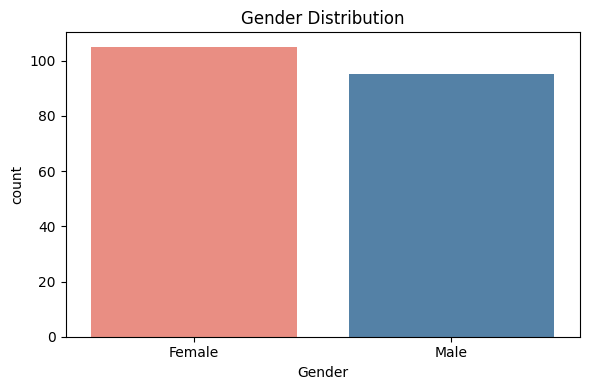

In [7]:
#EDA Visualizations:

#EXPLORATORY DATA ANALYSIS
# Rename columns for easier use
df.columns = ['CustomerID', 'Gender', 'Age', 'Income', 'SpendingScore']

# --- Plot 1: Gender Distribution ---
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Gender',
              hue='Gender',
              palette={'Male': 'steelblue', 'Female': 'salmon'},
              legend=False)
plt.title('Gender Distribution')
plt.tight_layout()
plt.show()

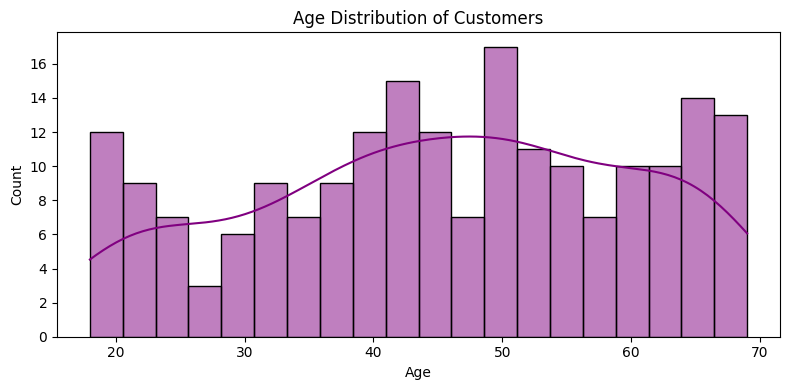

In [8]:
# --- Plot 2: Age Distribution ---
plt.figure(figsize=(8, 4))
sns.histplot(df['Age'], bins=20, kde=True, color='purple')
plt.title('Age Distribution of Customers')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

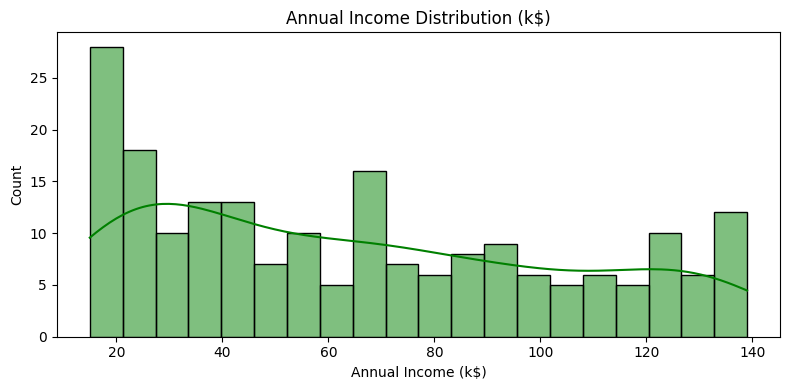

In [9]:
# --- Plot 3: Income Distribution ---
plt.figure(figsize=(8, 4))
sns.histplot(df['Income'], bins=20, kde=True, color='green')
plt.title('Annual Income Distribution (k$)')
plt.xlabel('Annual Income (k$)')
plt.tight_layout()
plt.show()

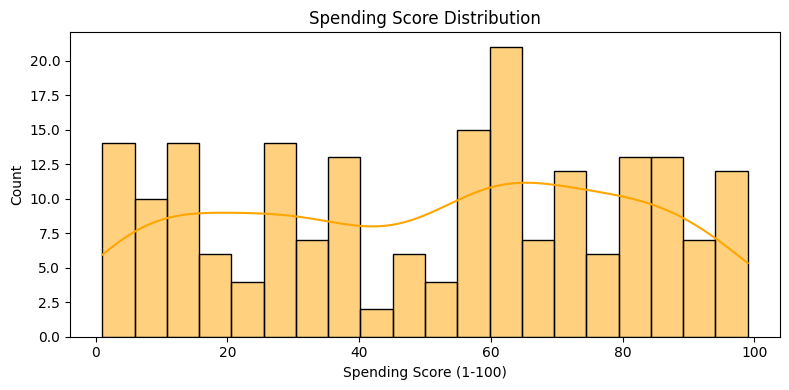

In [10]:
# --- Plot 4: Spending Score Distribution ---
plt.figure(figsize=(8, 4))
sns.histplot(df['SpendingScore'], bins=20, kde=True, color='orange')
plt.title('Spending Score Distribution')
plt.xlabel('Spending Score (1-100)')
plt.tight_layout()
plt.show()

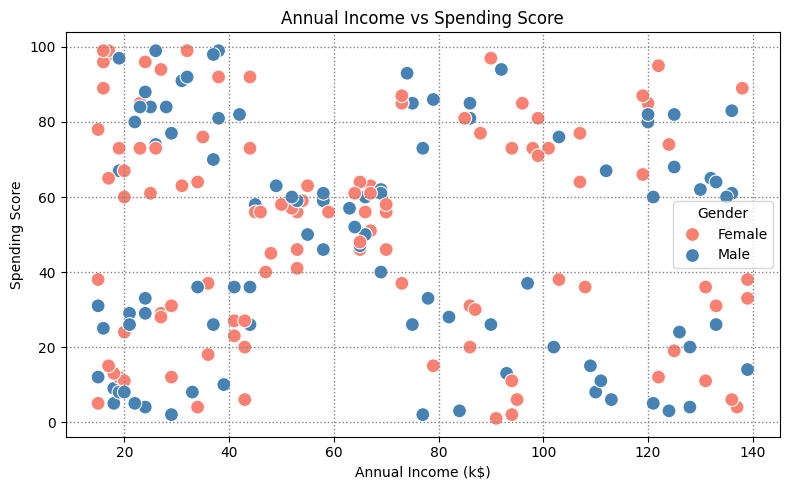

In [13]:
# --- Plot 5: Income vs Spending Score (KEY PLOT) ---
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Income', y='SpendingScore',
                hue='Gender',
                palette={'Male': 'steelblue', 'Female': 'salmon'},
                s=100)
plt.title('Annual Income vs Spending Score')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.grid(color='grey', linewidth=1 , linestyle=':')
plt.tight_layout()
plt.show()

K=1 → Inertia: 400.00
K=2 → Inertia: 244.50
K=3 → Inertia: 149.73
K=4 → Inertia: 88.50
K=5 → Inertia: 55.66
K=6 → Inertia: 45.67
K=7 → Inertia: 36.64
K=8 → Inertia: 31.27
K=9 → Inertia: 26.10
K=10 → Inertia: 22.85


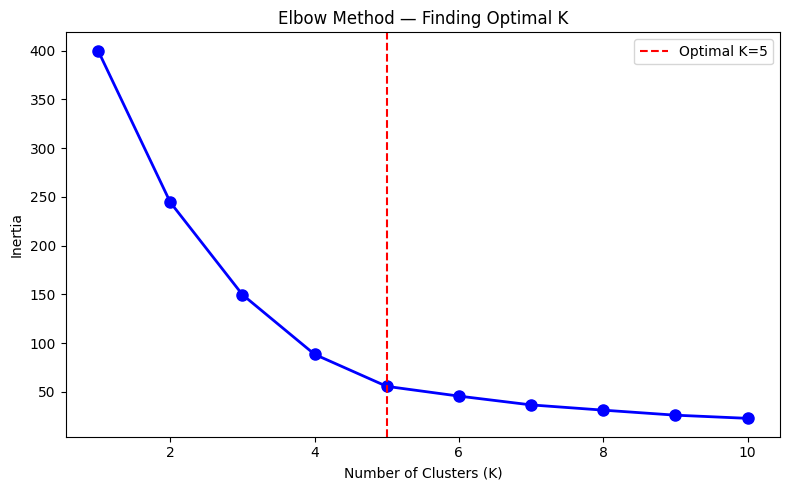


Look for the 'elbow' bend in the curve → that's your best K
Expected answer: K = 5


In [14]:
# FIND BEST NUMBER OF CLUSTERS
# Elbow Method: Try K=1 to K=10, plot inertia
# Inertia = how tight/compact the clusters are
# Lower inertia = better clusters
# We pick K where the curve bends like an "elbow"

# Use only Income and Spending Score for clustering
# These are the most meaningful features for segmentation
X = df[['Income', 'SpendingScore']]

# Scale features so both are on same range
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate inertia for K=1 to K=10
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    print(f"K={k} → Inertia: {kmeans.inertia_:.2f}")

# Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bo-', markersize=8, linewidth=2)
plt.axvline(x=5, color='red', linestyle='--',
            label='Optimal K=5')       # Mark the elbow
plt.title('Elbow Method — Finding Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.legend()
plt.tight_layout()
plt.show()

print("\nLook for the 'elbow' bend in the curve → that's your best K")
print("Expected answer: K = 5")

In [15]:
#APPLY K-MEANS WITH K=5
# Now we actually cluster customers into 5 groups

kmeans = KMeans(
    n_clusters=5,       # 5 clusters based on elbow method
    random_state=42,
    n_init=10           # Run 10 times, pick best result
)

# Fit and predict cluster labels
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster assignment done!")
print("\nCustomers per cluster:")
print(df['Cluster'].value_counts().sort_index())

print("\nCluster Centers (scaled):")
print(kmeans.cluster_centers_)

# See average Income & Spending per cluster
print("\nCluster Profiles:")
print(df.groupby('Cluster')[['Income', 'SpendingScore']].mean().round(1))

Cluster assignment done!

Customers per cluster:
Cluster
0    40
1    38
2    42
3    40
4    40
Name: count, dtype: int64

Cluster Centers (scaled):
[[-0.99816613  1.08784002]
 [ 1.13890232 -1.11736269]
 [-0.14057949  0.10161298]
 [-0.97486567 -1.05161818]
 [ 1.03868306  0.91857909]]

Cluster Profiles:
         Income  SpendingScore
Cluster                       
0          26.9           82.8
1         109.4           17.7
2          60.0           53.7
3          27.8           19.6
4         105.6           77.8


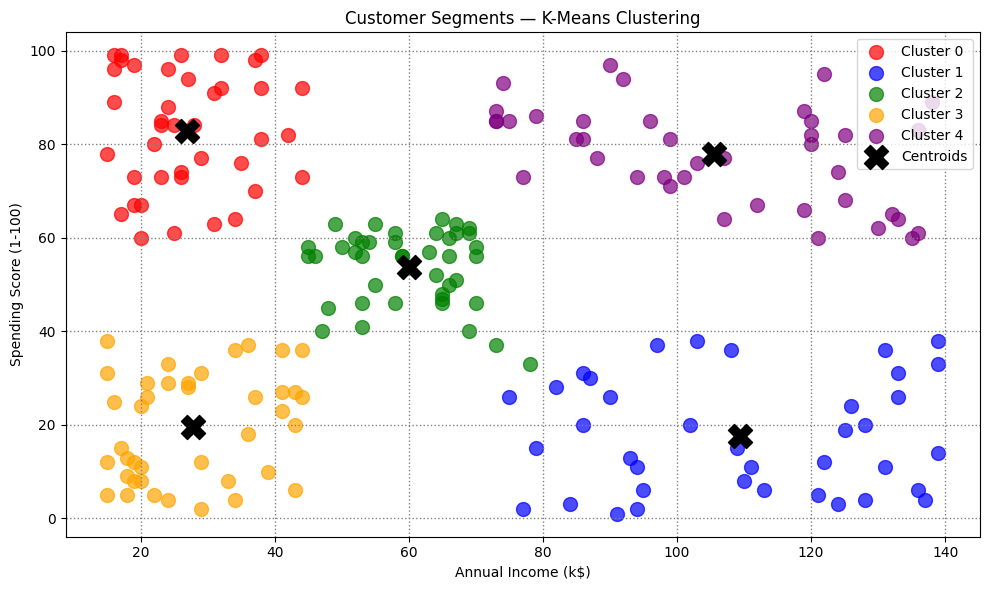

In [18]:
#VISUALIZE CLUSTERS
# Color palette for 5 clusters
colors = ['red', 'blue', 'green', 'orange', 'purple']

plt.figure(figsize=(10, 6))

# Plot each cluster separately
for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    plt.scatter(
        cluster_data['Income'],
        cluster_data['SpendingScore'],
        c=colors[i],
        label=f'Cluster {i}',
        s=100,
        alpha=0.7
    )

# Plot cluster centers
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centers[:, 0], centers[:, 1],
    c='black', marker='X',
    s=300, zorder=5,
    label='Centroids'
)

plt.title('Customer Segments — K-Means Clustering')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(color='grey', linewidth=1 , linestyle=':')
plt.tight_layout()
plt.show()

PCA Component 1 explains: 37.2%
PCA Component 2 explains: 32.5%
Total explained: 69.6%


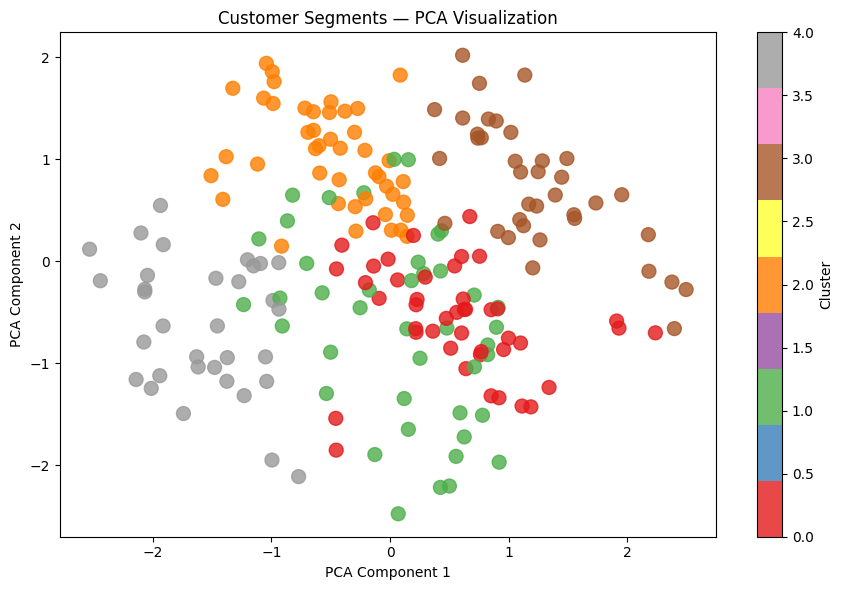

In [19]:
#  PCA — VISUALIZE IN 2D


# PCA = Principal Component Analysis
# Reduces many features to 2D so we can plot clusters
# Here we use all features (Age, Income, SpendingScore)

# Prepare all numeric features
X_all = df[['Age', 'Income', 'SpendingScore']]
X_all_scaled = scaler.fit_transform(X_all)

# Re-run K-Means on all 3 features
kmeans_all = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_All'] = kmeans_all.fit_predict(X_all_scaled)

# Apply PCA → reduce to 2 components for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_all_scaled)

# Check how much variance is explained
print(f"PCA Component 1 explains: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PCA Component 2 explains: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")

# Plot PCA clusters
plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=df['Cluster_All'],
    cmap='Set1',
    s=100,
    alpha=0.8
)
plt.colorbar(scatter, label='Cluster')
plt.title('Customer Segments — PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

In [21]:
# Label & Describe Each Cluster

# NAME EACH CLUSTER
# Based on Income and Spending Score patterns

# Map cluster numbers to meaningful names
cluster_names = {
    0: 'High Income, Low Spending → Careful Savers',
    1: 'High Income, High Spending → VIP Customers',
    2: 'Medium Income, Medium Spending → Average Customers',
    3: 'Low Income, High Spending → Impulsive Buyers',
    4: 'Low Income, Low Spending  → Budget Customers'
}

# Note: Your cluster numbers may differ — check the profile table above
# and reassign names based on what you see

print("=" * 55)
print("CLUSTER PROFILES & MARKETING STRATEGIES")
print("=" * 55)

profile = df.groupby('Cluster')[['Age','Income','SpendingScore']].mean().round(1)

for cluster_id, name in cluster_names.items():
    print(f"\nCluster {cluster_id}: {name}")
    if cluster_id in profile.index:
        row = profile.loc[cluster_id]
        print(f"  Avg Age:           {row['Age']}")
        print(f"  Avg Income:        ${row['Income']}k")
        print(f"  Avg Spending Score:{row['SpendingScore']}")

CLUSTER PROFILES & MARKETING STRATEGIES

Cluster 0: High Income, Low Spending → Careful Savers
  Avg Age:           45.2
  Avg Income:        $26.9k
  Avg Spending Score:82.8

Cluster 1: High Income, High Spending → VIP Customers
  Avg Age:           48.8
  Avg Income:        $109.4k
  Avg Spending Score:17.7

Cluster 2: Medium Income, Medium Spending → Average Customers
  Avg Age:           44.9
  Avg Income:        $60.0k
  Avg Spending Score:53.7

Cluster 3: Low Income, High Spending → Impulsive Buyers
  Avg Age:           44.4
  Avg Income:        $27.8k
  Avg Spending Score:19.6

Cluster 4: Low Income, Low Spending  → Budget Customers
  Avg Age:           44.1
  Avg Income:        $105.6k
  Avg Spending Score:77.8


In [22]:
# MARKETING STRATEGIES PER SEGMENT

strategies = {
    'VIP Customers\n(High Income, High Spending)': [
        '→ Offer exclusive membership cards',
        '→ Early access to new products',
        '→ Premium loyalty rewards'
    ],
    'Careful Savers\n(High Income, Low Spending)': [
        '→ Send targeted discount offers',
        '→ Highlight value for money',
        '→ Limited time deals to create urgency'
    ],
    'Impulsive Buyers\n(Low Income, High Spending)': [
        '→ Offer EMI / installment options',
        '→ Flash sales and daily deals',
        '→ Budget-friendly product bundles'
    ],
    'Budget Customers\n(Low Income, Low Spending)': [
        '→ Basic discount coupons',
        '→ Festival season promotions',
        '→ Affordable product range focus'
    ],
    'Average Customers\n(Medium Income, Medium Spending)': [
        '→ Personalized recommendations',
        '→ Mid-range loyalty program',
        '→ Weekend offers and cashback'
    ]
}

print("=" * 55)
print("MARKETING STRATEGIES PER CUSTOMER SEGMENT")
print("=" * 55)
for segment, tips in strategies.items():
    print(f"\n{segment}")
    for tip in tips:
        print(f"   {tip}")

MARKETING STRATEGIES PER CUSTOMER SEGMENT

VIP Customers
(High Income, High Spending)
   → Offer exclusive membership cards
   → Early access to new products
   → Premium loyalty rewards

Careful Savers
(High Income, Low Spending)
   → Send targeted discount offers
   → Highlight value for money
   → Limited time deals to create urgency

Impulsive Buyers
(Low Income, High Spending)
   → Offer EMI / installment options
   → Flash sales and daily deals
   → Budget-friendly product bundles

Budget Customers
(Low Income, Low Spending)
   → Basic discount coupons
   → Festival season promotions
   → Affordable product range focus

Average Customers
(Medium Income, Medium Spending)
   → Personalized recommendations
   → Mid-range loyalty program
   → Weekend offers and cashback


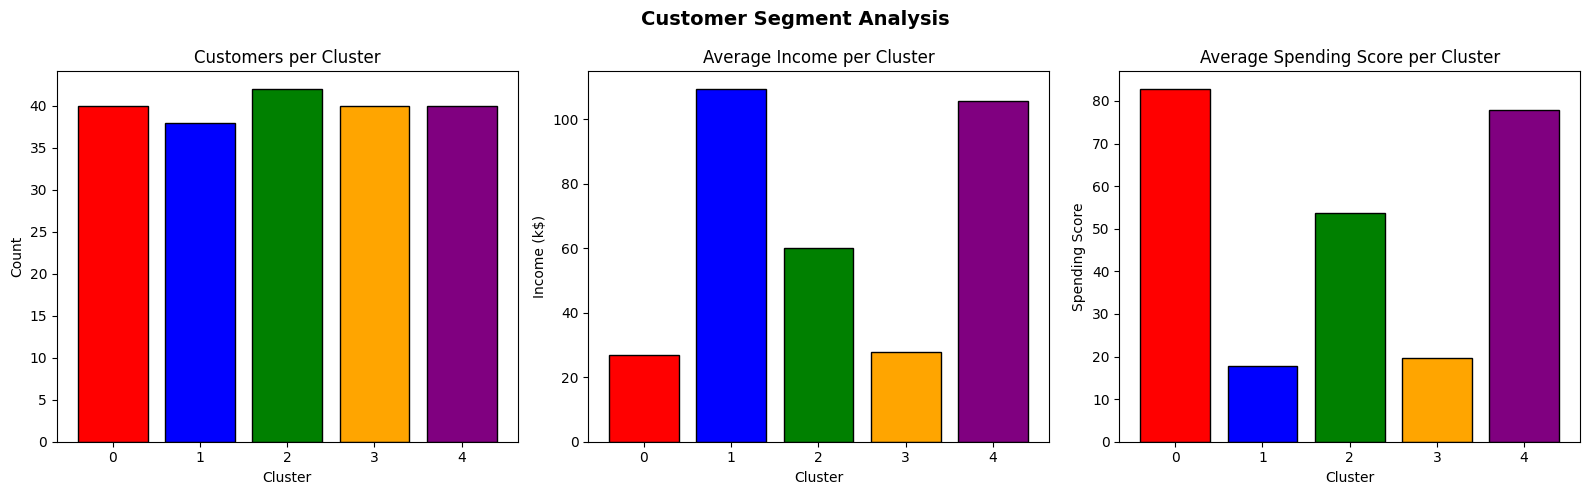

In [28]:
#   FINAL SUMMARY VISUALIZATION

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Cluster sizes
cluster_counts = df['Cluster'].value_counts().sort_index()
axes[0].bar(cluster_counts.index, cluster_counts.values,
            color=colors, edgecolor='black')
axes[0].set_title('Customers per Cluster')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Count')

# Plot 2: Average Income per Cluster
income_means = df.groupby('Cluster')['Income'].mean()
axes[1].bar(income_means.index, income_means.values,
            color=colors ,edgecolor='black')
axes[1].set_title('Average Income per Cluster')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Income (k$)')

# Plot 3: Average Spending Score per Cluster
spend_means = df.groupby('Cluster')['SpendingScore'].mean()
axes[2].bar(spend_means.index, spend_means.values,
            color=colors ,edgecolor='black')
axes[2].set_title('Average Spending Score per Cluster')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Spending Score')

plt.suptitle('Customer Segment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
